**QUESTION 6**

In [ ]:
import pandas as pd

df_ebola = pd.read_csv('drc_zones_timeseries-zonal.csv')
#clean the data of all occurence of "Haut-UÃ©lÃ©"
df_ebola["Province"] = df_ebola["Province"].replace("Haut-UÃ©lÃ©", "Haut-Uele")
print(df_ebola.head())

        Date Health Zone Province  Confirmed Cases  Confirmed Deaths
0  5/14/2026   Mongbwalu    Ituri                0               NaN
1  5/15/2026       Bunia    Ituri                0               NaN
2  5/15/2026   Mongbwalu    Ituri                0               NaN
3  5/15/2026    Rwampara    Ituri               13               NaN
4  5/18/2026       Bunia    Ituri                6               NaN


In [ ]:
# group all the provinces together in a dataframe, obtain their sum, check if it is greater than 0 and count the number of rows
provinces_df = df_ebola.groupby("Province")

provinces_df = provinces_df["Confirmed Cases"].sum()

provinces_df = provinces_df[provinces_df > 0]

print(provinces_df.count())

5


There are **5** DRC provinces affected.

In [ ]:
#aggregate the data into a single national daily series and fill up missing dates
nationaldaily_df = (df_ebola.groupby("Date").sum()[["Confirmed Cases", "Confirmed Deaths"]])

print(nationaldaily_df.head())

           Confirmed Cases  Confirmed Deaths
Date                                        
5/14/2026                0               0.0
5/15/2026               13               0.0
5/18/2026               33               0.0
5/19/2026               51               0.0
5/20/2026               57               0.0


In [ ]:
#get the cumulative cases and deaths by getting the last value in the series

print(f'The cumulative number of cases is: {nationaldaily_df["Confirmed Cases"].iloc[-1]}')
print(f'The cumulative number of deaths is: {nationaldaily_df["Confirmed Deaths"].iloc[-1]}')

The cumulative number of cases is: 3973
The cumulative number of deaths is: 1801.0


In [ ]:

#to calculate the  number of missing dates

df_ebola["Date"] = pd.to_datetime(df_ebola["Date"])
print(len(pd.date_range(
  start="2026-05-14", end="2026-08-04").difference(df_ebola["Date"])))


11


In [ ]:
nationaldaily_df = nationaldaily_df.asfreq('D')
nationaldaily_df = nationaldaily_df.interpolate(method='linear')

#I discovered that the Confirmed Deaths for 2026-06-16 did not interpolate, I am still trying to find why, however,
# I interpolated it manually.
nationaldaily_df.loc['2026-06-16', "Confirmed Deaths"] = (
    nationaldaily_df.loc['2026-06-15', "Confirmed Deaths"] +
    nationaldaily_df.loc['2026-06-17', "Confirmed Deaths"]
) / 2
print(nationaldaily_df.head())

            Confirmed Cases  Confirmed Deaths
Date                                         
2026-05-14         0.000000               0.0
2026-05-15        13.000000               0.0
2026-05-16        19.666667               0.0
2026-05-17        26.333333               0.0
2026-05-18        33.000000               0.0


In [ ]:
#filter the index when cumulative cases is greater than 100
print(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 100].index)

DatetimeIndex(['2026-05-24', '2026-05-26', '2026-05-27', '2026-05-28',
               '2026-05-29', '2026-05-30', '2026-05-31', '2026-06-01',
               '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05',
               '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09',
               '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13',
               '2026-06-14', '2026-06-15', '2026-06-16', '2026-06-17',
               '2026-06-18', '2026-06-19', '2026-06-20', '2026-06-21',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-27', '2026-06-28', '2026-06-29',
               '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03',
               '2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07',
               '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11',
               '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19',
      

In [ ]:
#filter the index when cumulative cases is greater than 500
print(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 500].index)

DatetimeIndex(['2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11',
               '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15',
               '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19',
               '2026-06-20', '2026-06-21', '2026-06-22', '2026-06-23',
               '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-27',
               '2026-06-28', '2026-06-29', '2026-06-30', '2026-07-01',
               '2026-07-02', '2026-07-03', '2026-07-04', '2026-07-05',
               '2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09',
               '2026-07-10', '2026-07-11', '2026-07-12', '2026-07-13',
               '2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17',
               '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21',
               '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-25',
               '2026-07-26', '2026-07-27', '2026-07-28', '2026-07-29',
               '2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02',
      

In [ ]:
#filter the index when cumulative cases is greater than 1000
print(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 1000].index)

DatetimeIndex(['2026-06-21', '2026-06-22', '2026-06-23', '2026-06-24',
               '2026-06-25', '2026-06-26', '2026-06-27', '2026-06-28',
               '2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02',
               '2026-07-03', '2026-07-04', '2026-07-05', '2026-07-06',
               '2026-07-07', '2026-07-08', '2026-07-09', '2026-07-10',
               '2026-07-11', '2026-07-12', '2026-07-13', '2026-07-14',
               '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-18',
               '2026-07-19', '2026-07-20', '2026-07-21', '2026-07-22',
               '2026-07-23', '2026-07-24', '2026-07-25', '2026-07-26',
               '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30',
               '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03',
               '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


In [ ]:
#filter the index when cumulative cases is greater than 2000
print(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 2000].index)

DatetimeIndex(['2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17',
               '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21',
               '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-25',
               '2026-07-26', '2026-07-27', '2026-07-28', '2026-07-29',
               '2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02',
               '2026-08-03', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


In [ ]:
#filter the index when cumulative cases is greater than 3500
print(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 3500].index)

DatetimeIndex(['2026-07-29', '2026-07-30', '2026-07-31', '2026-08-01',
               '2026-08-02', '2026-08-03', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


**PLOT THE CUMULATIVE CASES AGAINST THE DATES**

In [ ]:
#filter the dates where cumulative cases is greater than 100
x4points = (list(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 100].index.strftime('%Y-%m-%d')))
print(x4points)


['2026-05-24', '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29', '2026-05-30', '2026-05-31', '2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05', '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19', '2026-06-20', '2026-06-21', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-27', '2026-06-28', '2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03', '2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11', '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-25', '2026-07-26', '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03', '2026

In [ ]:
#get the confirmed cases when cumulative cases is greater than 100
y4points = (list(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 100]["Confirmed Cases"]))
print(y4points)

[101.0, 111.0, 119.0, 243.0, 243.0, 243.0, 246.5, 250.0, 269.0, 281.0, 356.0, 394.0, 421.0, 456.0, 502.0, 541.0, 582.0, 595.0, 641.5, 688.0, 714.0, 776.0, 781.0, 880.0, 916.0, 939.0, 986.0, 1031.0, 1077.0, 1098.0, 1138.0, 1186.0, 1218.5, 1251.0, 1283.5, 1316.0, 1389.0, 1443.0, 1485.0, 1511.0, 1544.0, 1607.0, 1691.0, 1742.0, 1772.0, 1813.0, 1861.0, 1909.0, 1951.5, 1994.0, 2056.0, 2107.0, 2178.5, 2250.0, 2327.0, 2406.0, 2456.0, 2519.0, 2905.0, 2973.0, 3075.0, 3200.0, 3262.0, 3360.0, 3441.6666666666665, 3523.3333333333335, 3605.0, 3674.0, 3748.0, 3802.0, 3874.0, 3973.0]


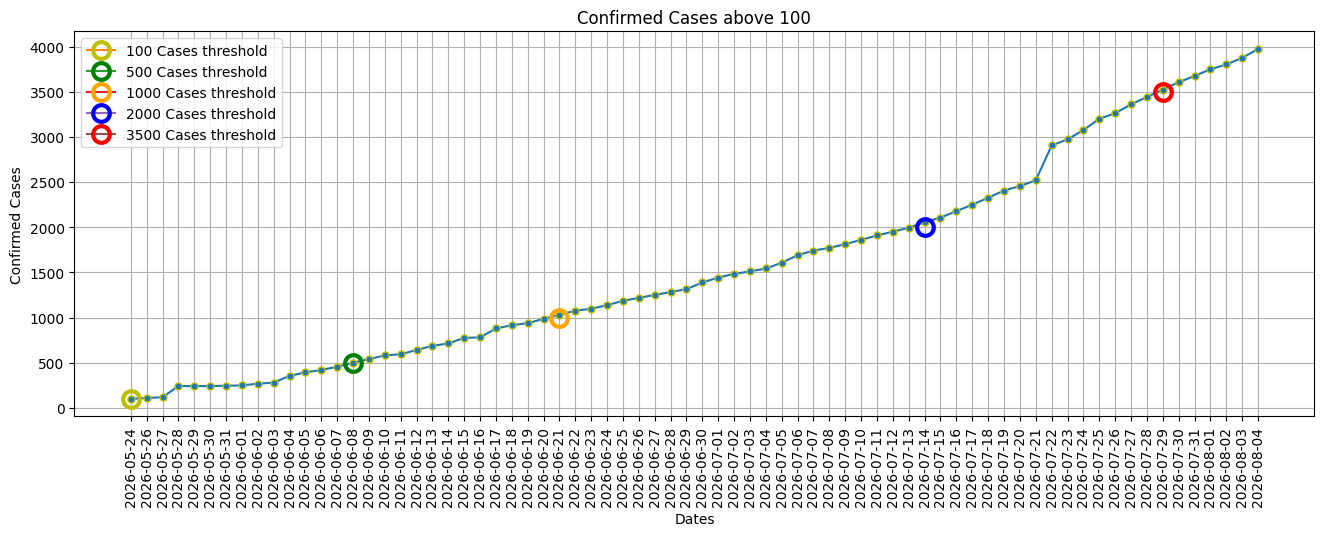

In [ ]:
# the graph needs to be made larger and the dates has to be rotated for proper viewing
plt.figure(figsize=(16, 5))
plt.xticks(rotation=90)

plt.plot(x4points, y4points, marker = 'o', mec = 'y', ms = 5)
plt.xlabel("Dates")
plt.ylabel("Confirmed Cases")
plt.title("Confirmed Cases above 100")


# thresholds of 100, 500, 1000, 2000 and 3500 confirmed cases
plt.plot('2026-05-24', 100, marker='o', ms=12, mfc='none', mec='y', mew=3, label='100 Cases threshold')
plt.plot('2026-06-08', 500, marker='o', ms=12, mfc='none', mec='g', mew=3, label='500 Cases threshold')
plt.plot('2026-06-21', 1000, marker='o', ms=12, mfc='none', mec='orange', mew=3, label='1000 Cases threshold')
plt.plot('2026-07-14', 2000, marker='o', ms=12, mfc='none', mec='b', mew=3, label='2000 Cases threshold')
plt.plot('2026-07-29', 3500, marker='o', ms=12, mfc='none', mec='r', mew=3, label='3500 Cases threshold')

plt.legend()
plt.grid()
plt.show()

In [ ]:
#filter the index when cumulative deaths is greater than 50
print(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 50].index)

DatetimeIndex(['2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05',
               '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09',
               '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13',
               '2026-06-14', '2026-06-15', '2026-06-16', '2026-06-17',
               '2026-06-18', '2026-06-19', '2026-06-20', '2026-06-21',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-27', '2026-06-28', '2026-06-29',
               '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03',
               '2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07',
               '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11',
               '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19',
               '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23',
               '2026-07-24', '2026-07-25', '2026-07-26', '2026-07-27',
      

In [ ]:
#filter the index when cumulative deaths is greater than 100
print(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 100].index)

DatetimeIndex(['2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11',
               '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15',
               '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19',
               '2026-06-20', '2026-06-21', '2026-06-22', '2026-06-23',
               '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-27',
               '2026-06-28', '2026-06-29', '2026-06-30', '2026-07-01',
               '2026-07-02', '2026-07-03', '2026-07-04', '2026-07-05',
               '2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09',
               '2026-07-10', '2026-07-11', '2026-07-12', '2026-07-13',
               '2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17',
               '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21',
               '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-25',
               '2026-07-26', '2026-07-27', '2026-07-28', '2026-07-29',
               '2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02',
      

In [ ]:
#filter the index when cumulative deaths is greater than 500
print(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 500].index)

DatetimeIndex(['2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07',
               '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11',
               '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19',
               '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23',
               '2026-07-24', '2026-07-25', '2026-07-26', '2026-07-27',
               '2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31',
               '2026-08-01', '2026-08-02', '2026-08-03', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


In [ ]:
#filter the index when cumulative deaths is greater than 1000
print(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 1000].index)

DatetimeIndex(['2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24',
               '2026-07-25', '2026-07-26', '2026-07-27', '2026-07-28',
               '2026-07-29', '2026-07-30', '2026-07-31', '2026-08-01',
               '2026-08-02', '2026-08-03', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


In [ ]:
#filter the index when cumulative deaths is greater than 1500
print(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 1500].index)

DatetimeIndex(['2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31',
               '2026-08-01', '2026-08-02', '2026-08-03', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


**PLOT THE CUMULATIVE DEATHS AGAINST THE DATES**

In [ ]:
#filter the dates where cumulative deaths is greater than 50
x5points = (list(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 50].index.strftime('%Y-%m-%d')))
print(x5points)


#get the confirmed deaths when cumulative deaths is greater than 50
y5points = (list(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 50]["Confirmed Deaths"]))
print(y5points)

['2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05', '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19', '2026-06-20', '2026-06-21', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-27', '2026-06-28', '2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03', '2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11', '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-25', '2026-07-26', '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03', '2026-08-04']
[52.0, 53.0, 72.0, 76.0, 81.0, 91.0, 105.0, 117.0, 126.0, 132.0, 151.5, 171.0, 182.0, 186.0, 209.5, 233

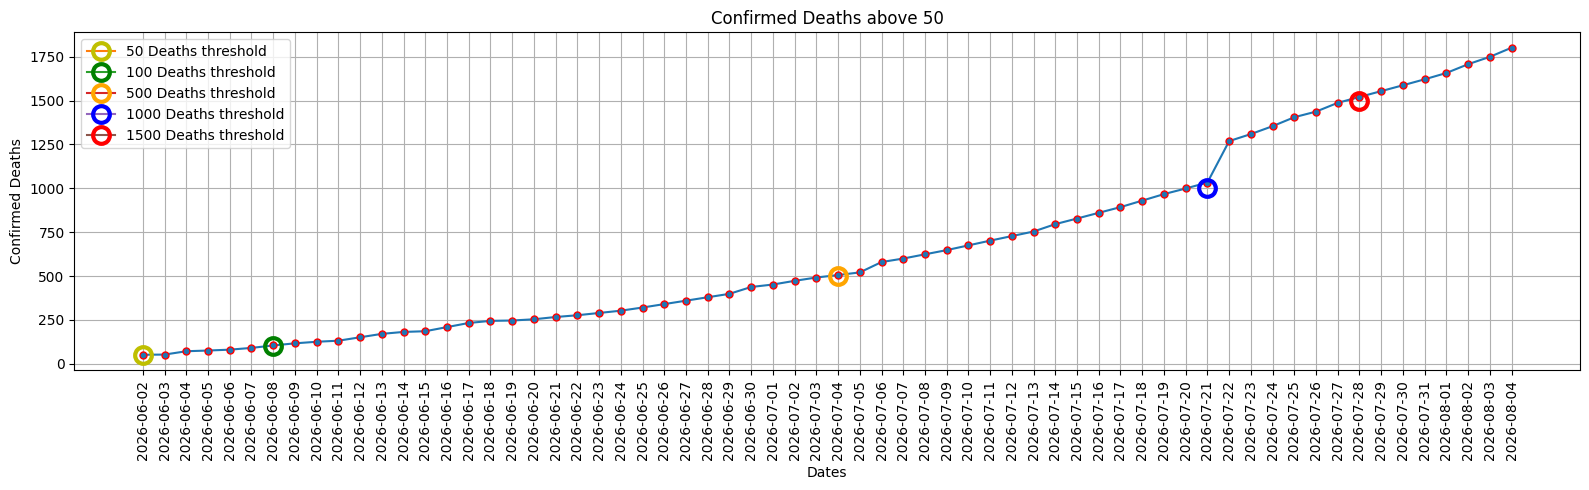

In [ ]:
import matplotlib.pyplot as plt

# the graph needs to be made larger and the dates has to be rotated for proper viewing
plt.figure(figsize=(16, 5))
plt.xticks(rotation=90)

plt.plot(x5points, y5points, marker = 'o', mec = 'r', ms = 5)
plt.xlabel("Dates")
plt.ylabel("Confirmed Deaths")
plt.title("Confirmed Deaths above 50")

# thresholds of 50, 100, 500, 1000 and 1500 confirmed deaths
plt.plot('2026-06-02', 50, marker='o', ms=12, mfc='none', mec='y', mew=3, label='50 Deaths threshold')
plt.plot('2026-06-08', 100, marker='o', ms=12, mfc='none', mec='g', mew=3, label='100 Deaths threshold')
plt.plot('2026-07-04', 500, marker='o', ms=12, mfc='none', mec='orange', mew=3, label='500 Deaths threshold')
plt.plot('2026-07-21', 1000, marker='o', ms=12, mfc='none', mec='b', mew=3, label='1000 Deaths threshold')
plt.plot('2026-07-28', 1500, marker='o', ms=12, mfc='none', mec='r', mew=3, label='1500 Deaths threshold')

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


**e.** Plot cumulative deaths against cumulative cases, and discuss the case fatality rate among confirmed cases.

In [ ]:
# put cumululative deaths into an array
y6points = list(nationaldaily_df["Confirmed Deaths"])
print(y6points)

#put cumulative cases into an array
x6points = list(nationaldaily_df["Confirmed Cases"])
print(x6points)


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 43.0, 42.0, 42.0, 46.0, 50.0, 52.0, 53.0, 72.0, 76.0, 81.0, 91.0, 105.0, 117.0, 126.0, 132.0, 151.5, 171.0, 182.0, 186.0, 209.5, 233.0, 245.0, 247.0, 254.0, 267.0, 277.0, 290.0, 303.0, 321.0, 340.5, 360.0, 379.5, 399.0, 438.0, 452.0, 473.0, 492.0, 506.0, 521.0, 580.0, 600.0, 624.0, 648.0, 675.0, 702.0, 728.0, 754.0, 796.0, 828.0, 860.5, 893.0, 930.0, 967.0, 999.0, 1033.0, 1269.0, 1309.0, 1354.0, 1405.0, 1437.0, 1487.0, 1520.3333333333333, 1553.6666666666667, 1587.0, 1621.0, 1657.0, 1707.0, 1749.0, 1801.0]
[0.0, 13.0, 19.666666666666668, 26.333333333333336, 33.0, 51.0, 57.0, 79.0, 83.0, 95.0, 101.0, 100.0, 111.0, 119.0, 243.0, 243.0, 243.0, 246.5, 250.0, 269.0, 281.0, 356.0, 394.0, 421.0, 456.0, 502.0, 541.0, 582.0, 595.0, 641.5, 688.0, 714.0, 776.0, 781.0, 880.0, 916.0, 939.0, 986.0, 1031.0, 1077.0, 1098.0, 1138.0, 1186.0, 1218.5, 1251.0, 1283.5, 1316.0, 1389.0, 1443.0, 1485.0, 1511.0, 1544.0, 1607.0, 1691.0, 1742.0

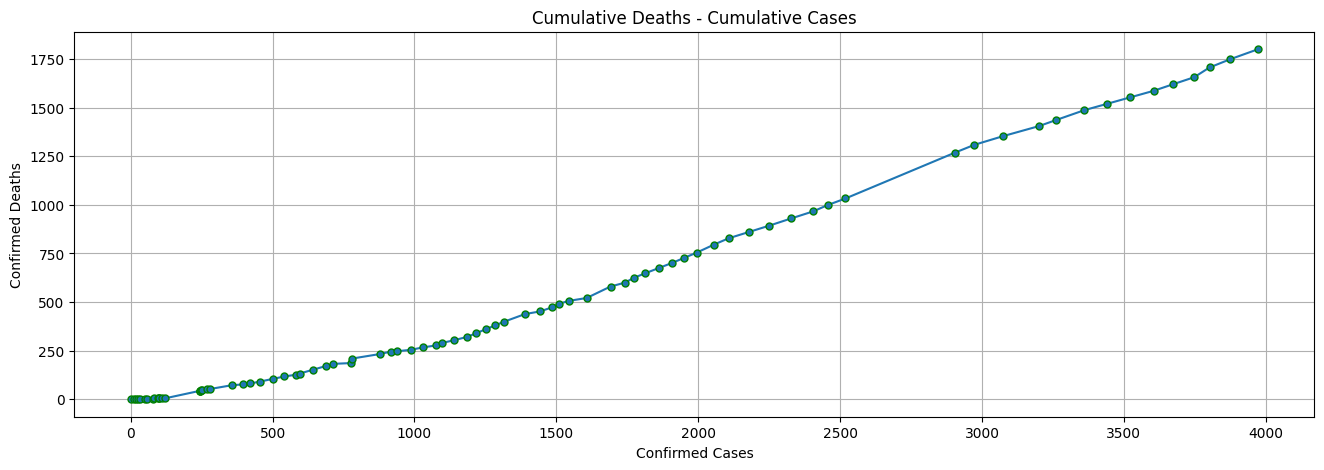

In [ ]:
plt.figure(figsize=(16, 5))

plt.plot(x6points, y6points, marker = 'o', mec = 'g', ms = 5)
plt.xlabel("Confirmed Cases")
plt.ylabel("Confirmed Deaths")
plt.title("Cumulative Deaths - Cumulative Cases")


plt.grid()
plt.show()